ADF Statistic : -0.7211
p-value : 0.8412
Series is non-stationary → using d = 2


c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

                               SARIMAX Results                                
Dep. Variable:                    sst   No. Observations:                  441
Model:               ARIMA(12, 2, 12)   Log Likelihood                 908.387
Date:                Wed, 11 Feb 2026   AIC                          -1766.773
Time:                        13:04:59   BIC                          -1664.661
Sample:                             0   HQIC                         -1726.486
                                - 441                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4858      0.752     -0.646      0.518      -1.960       0.988
ar.L2         -0.3402      0.456     -0.746      0.456      -1.234       0.554
ar.L3         -0.5284      0.593     -0.890      0.3

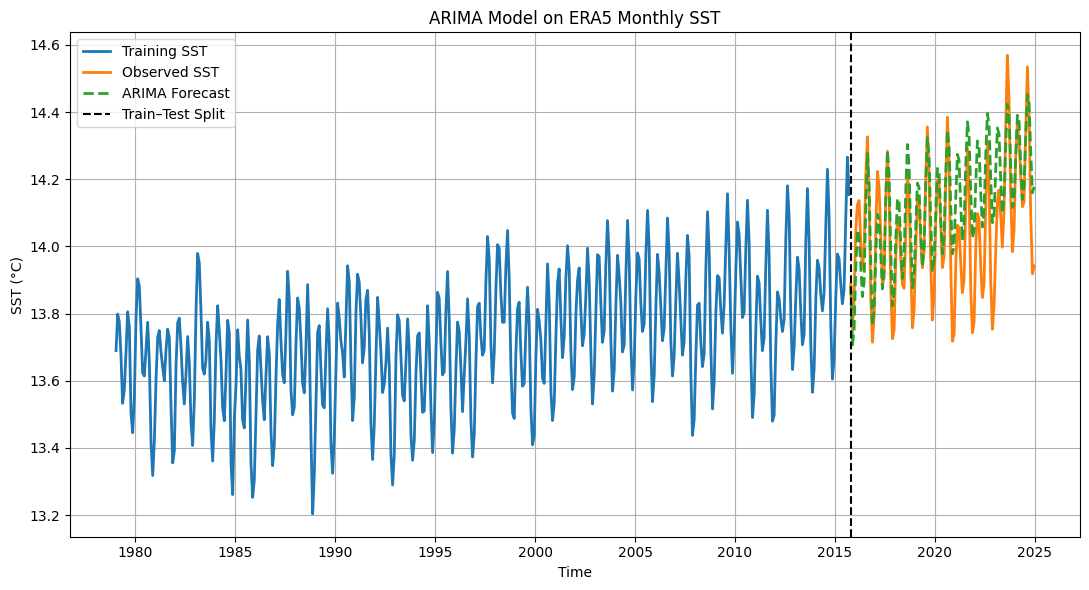

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
sst_file_path = r"D:\\NITD\\2nd Sem\\Computational Simulation Lab\\ERA5_SST_sst_K_monmean_7924_1.nc"
ds = xr.open_dataset(sst_file_path)
sst = ds["sst"]
# Spatial mean (global or regional mean SST)
sst_series = sst.mean(dim=["lat", "lon"], skipna=True).values
time = pd.to_datetime(ds["time"].values)
# Convert Kelvin to Celsius
sst_celsius = sst_series - 273.15
scaler = MinMaxScaler(feature_range=(0, 1))
sst_norm = scaler.fit_transform(sst_celsius.reshape(-1, 1)).flatten()

df = pd.DataFrame({
    "time": time,
    "sst": sst_norm
}).dropna()

df.set_index("time", inplace=True)
adf_result = adfuller(df["sst"])
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value : {adf_result[1]:.4f}")
# Decide differencing order d
if adf_result[1] > 0.05:
    d = 2
    print("Series is non-stationary → using d = 2")
else:
    d = 0
    print("Series is stationary → using d = 0")

train_size = int(len(df) * 0.8)
train = df["sst"].iloc[:train_size]
test = df["sst"].iloc[train_size:]

p = 12
q = 12

model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

print(model_fit.summary())

forecast = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"RMSE (normalized SST): {rmse:.4f}")

train_inv = scaler.inverse_transform(train.values.reshape(-1, 1)).flatten()
test_inv = scaler.inverse_transform(test.values.reshape(-1, 1)).flatten()
forecast_inv = scaler.inverse_transform(forecast.values.reshape(-1, 1)).flatten()

plt.figure(figsize=(11, 6))

plt.plot(df.index[:train_size], train_inv,
         label="Training SST", linewidth=2)

plt.plot(df.index[train_size:], test_inv,
         label="Observed SST", linewidth=2)

plt.plot(df.index[train_size:], forecast_inv,
         label="ARIMA Forecast", linestyle="--", linewidth=2)

plt.axvline(df.index[train_size],
            color="black", linestyle="--", label="Train–Test Split")

plt.xlabel("Time")
plt.ylabel("SST (°C)")
plt.title("ARIMA Model on ERA5 Monthly SST")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

ADF Statistic : -0.7211
p-value : 0.8412
Series is non-stationary → using d = 1


c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                sst   No. Observations:                  441
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 782.987
Date:                            Wed, 11 Feb 2026   AIC                          -1555.974
Time:                                    13:05:07   BIC                          -1535.845
Sample:                                         0   HQIC                         -1548.014
                                            - 441                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3382      0.713     -0.474      0.635      -1.736       1.059
ma.L1          0.2945      0.721   

c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\V.Sree Chaitran\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


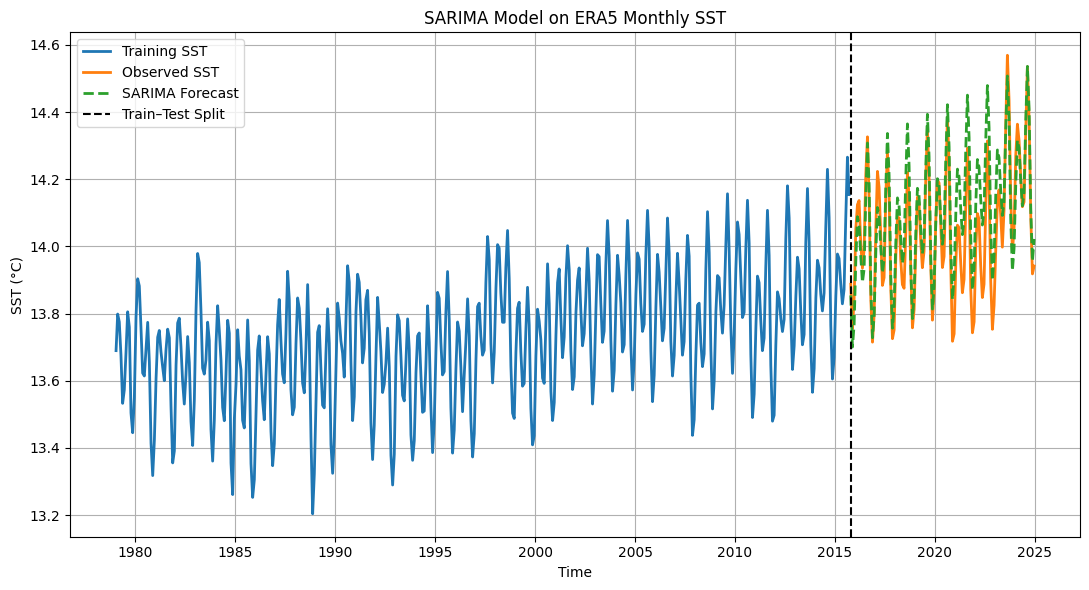

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

# =============================
# Load NetCDF File
# =============================

sst_file_path = r"D:\\NITD\\2nd Sem\\Computational Simulation Lab\\ERA5_SST_sst_K_monmean_7924_1.nc"
ds = xr.open_dataset(sst_file_path)

sst = ds["sst"]

# =============================
# Spatial Mean SST
# =============================

sst_series = sst.mean(dim=["lat", "lon"], skipna=True).values
time = pd.to_datetime(ds["time"].values)

# Convert Kelvin → Celsius
sst_celsius = sst_series - 273.15

df = pd.DataFrame({
    "time": time,
    "sst": sst_celsius
}).dropna()

df.set_index("time", inplace=True)

# =============================
# ADF Test
# =============================

adf_result = adfuller(df["sst"])

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value : {adf_result[1]:.4f}")

if adf_result[1] > 0.05:
    d = 1
    print("Series is non-stationary → using d = 1")
else:
    d = 0
    print("Series is stationary → using d = 0")

# =============================
# Train-Test Split
# =============================

train_size = int(len(df) * 0.8)
train = df["sst"].iloc[:train_size]
test = df["sst"].iloc[train_size:]

# =============================
# SARIMA Model
# Monthly Data → seasonality = 12
# =============================

model = SARIMAX(train,
                order=(1, d, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit()

print(model_fit.summary())

# =============================
# Forecast
# =============================

forecast = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"RMSE (°C): {rmse:.4f}")

# =============================
# Plot Results
# =============================

plt.figure(figsize=(11, 6))

plt.plot(df.index[:train_size], train,
         label="Training SST", linewidth=2)

plt.plot(df.index[train_size:], test,
         label="Observed SST", linewidth=2)

plt.plot(df.index[train_size:], forecast,
         label="SARIMA Forecast", linestyle="--", linewidth=2)

plt.axvline(df.index[train_size],
            color="black", linestyle="--", label="Train–Test Split")

plt.xlabel("Time")
plt.ylabel("SST (°C)")
plt.title("SARIMA Model on ERA5 Monthly SST")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()